# HOMEWORK 5

In this homework you are going to implement the **Floyd-Steinberg dithering** algorithm. Dithering, in general, means that we are adding noise to the signal (in our case digital image) in order to perceive it better. In other words, by adding the noise the objective quality will be worse but the subjective quality will be better (i.e. the image will "look" better).

The details of FS dithering can be found in this [wiki](https://en.wikipedia.org/wiki/Floyd%E2%80%93Steinberg_dithering) page. In order to implement the dithering, we will implement the following steps:
* Define colour palette
* Quantize the image to obtain the baseline and compute the average quantization error
* Implement FS dithering and compute the average quantization error

You will also have to answer the question at the end of this notebook.

Note: In this homework, you will have the chance to earn some extra points. See the "Bonus" section at the end of the notebook. Good luck!

As always, you are encouraged to use your own images :-)

In [142]:
import cv2
import math
import time
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image.

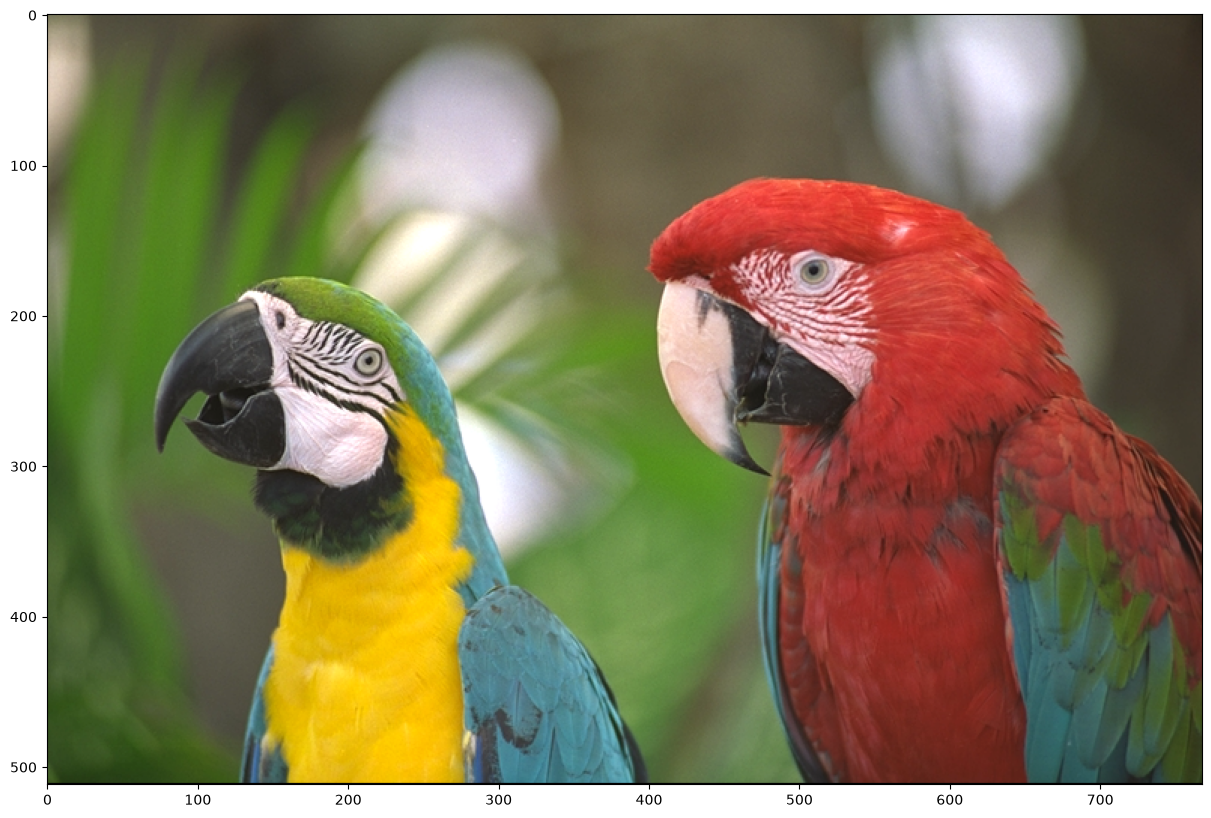

In [143]:
# Load image
img = cv2.imread('../data/kodim23.png')
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Plot it
plt.imshow(img)

Let's start with gray tones first.

In [144]:
# Black, dark gray, light gray, white
colors = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]])

Both parts of the homework need the same operation: given a pixel, find the closest colour of the
palette. Let's write it once as a small function and reuse it.

In [145]:
def closest_color_euclidian_squared(pixel, colors):
    # Compute the distance from the pixel to every colour of the palette
    # Hint: colors - pixel gives you all the differences at once
    distances = np.sum((colors - pixel)**2, axis=1)
    # Return the colour of the palette with the smallest distance
    return colors[np.argmin(distances)]

def closest_color_euclidian_numpy(pixel, colors):
    # Compute the distance from the pixel to every colour of the palette
    # Hint: colors - pixel gives you all the differences at once
    distances = np.linalg.norm(colors - pixel, axis=1)
    # Return the colour of the palette with the smallest distance
    return colors[np.argmin(distances)]

Using the colour palette, let's quantize the original image. This is our baseline: every pixel is
replaced by the closest palette colour, independently of its neighbours.

In [146]:
def quantize_image(img, colors):
    # Cast the image to float (the quantization error can be negative and larger than 255)
    img = img.astype(np.float32)    
    # Prepare for quantization
    rows, cols, channels = img.shape
    quantized = np.zeros_like(img)
    
    # just a small note, made a performance test for both functions and time to calculate the nearest color
    # closest_color_euclidian_squared: ~1.72s
    # closest_color_euclidian_numpy: ~1.8s
    # the difference in our case is a faction of second, but imagine processing more data and with higher image resolution
    # eliminating square root could be some tiny worth taking optimization
    
    # Apply quantization
    for r in range(rows):
        for c in range(cols):
            # Extract the original pixel value
            pixel = img[r][c]
            # Find the closest colour from the palette
            new_pixel = closest_color_euclidian_numpy(pixel, colors)
            # Apply quantization
            quantized[r, c, :] = new_pixel
    
    quantized = np.clip(quantized, 0, 255).astype(np.uint8)
    return quantized

quantized = quantize_image(img, colors)


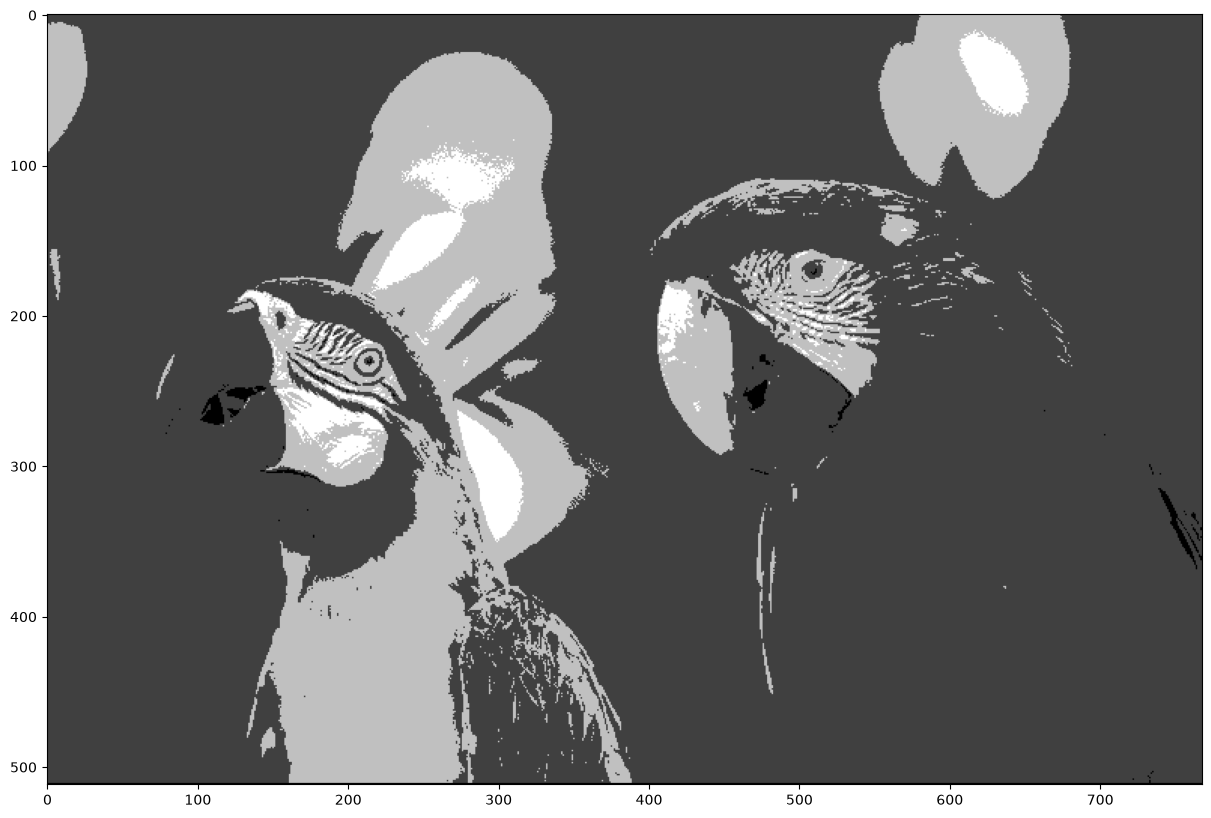

In [147]:
# Show quantized image (don't forget to cast back to uint8)
plt.imshow(quantized)

To be able to compare the two approaches we need a number. Let's use the **average quantization error**,
i.e. the mean absolute difference between the original and the quantized image, averaged over all pixels
and all three channels.

In [148]:
# Compute average quantization error
def avg_quantization_error(img, quantized):
   return  np.mean(np.abs(img.astype(np.float32) - quantized.astype(np.float32)))

avg_quant_error = avg_quantization_error(img, quantized)
print("avg_quant_error: ", avg_quant_error)

avg_quant_error:  32.757755


#### Floyd-Steinberg Dithering

We are now going to implement the FS dithering and compare it to the optimally quantized image we have
calculated above.

The idea is a **feedback loop**: after quantizing a pixel we know exactly how much we got it wrong,

$$ \varepsilon = p_{orig} - p_{quant} $$

and we push that error onto the neighbours that have not been processed yet. If a pixel was made too
dark, its neighbours are made brighter on purpose, so that the error averages out to zero over a small
area. The error is distributed according to the FS diffusion matrix (`*` marks the current pixel, the
image is scanned left to right, top to bottom)

$$ \frac{1}{16}
\begin{bmatrix}
 - & * & 7 \\
 3 & 5 & 1
\end{bmatrix} $$

so the pixel to the right receives 7/16 of the error, the one below-left 3/16, the one below 5/16 and
the one below-right 1/16.

Two practical notes:
* The diffused error has to be accumulated in a **copy** of the image (`img_tmp`). Each pixel must be
  quantized using the value that already contains the error of its neighbours, not the original value.
* We skip the first and the last row and column so that we do not have to handle the borders, which is
  why the loop starts at 1.

In [149]:
def fs_dithering(img, colors):
    # Cast the image to float (the quantization error can be negative and larger than 255)
    img = img.astype(np.float32)   
     # Make a temporal copy of the original image, we will need it for error diffusion
    img_tmp = np.copy(img)
    dithering = np.zeros_like(img)
    
    for r in range(1, rows-1):
        for c in range(1, cols-1):
            # Extract the pixel value, including the error diffused from the neighbours
            pixel = img_tmp[r, c]
            # Find the closest colour from the palette
            new_pixel = closest_color_euclidian_numpy(pixel, colors)
            # Compute quantization error
            quant_error = pixel - new_pixel
            # Diffuse the quantization error according to the FS diffusion matrix
            # Note: You need more than one line of code here
            img_tmp[r, c+1, :] += quant_error * 7/16
            img_tmp[r+1, c-1, :] += quant_error * 3/16
            img_tmp[r+1, c, :] += quant_error * 5/16
            img_tmp[r+1, c+1, :] += quant_error * 1/16
            # Apply dithering
            dithering[r, c, :] = new_pixel

    dithering = np.clip(dithering, 0, 255).astype(np.uint8)
    return dithering
    
dithering = fs_dithering(img, colors)

(<Axes: >, <matplotlib.image.AxesImage at 0x1d263240b90>)

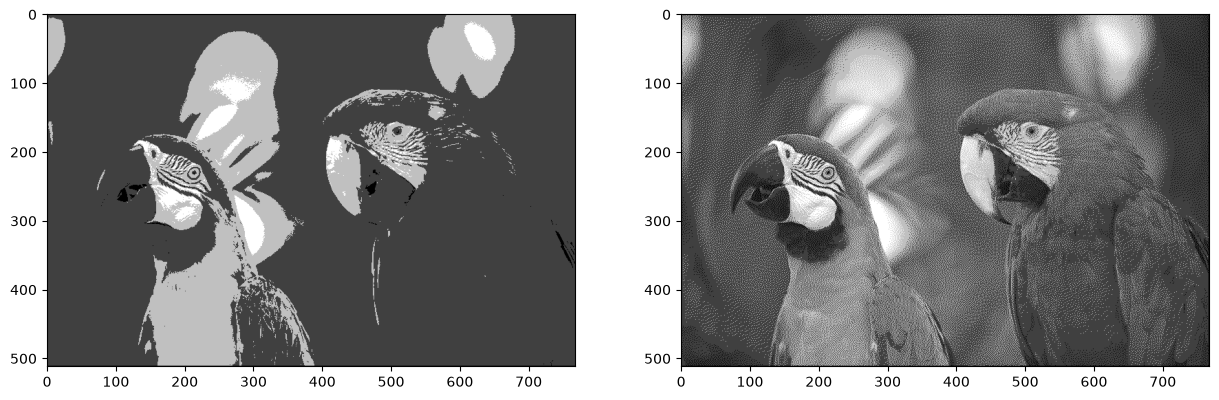

In [150]:
# Show quantized image (don't forget to cast back to uint8)
plt.subplot(121), plt.imshow(quantized)   # optimally quantized
plt.subplot(122), plt.imshow(dithering)   # dithering

In [151]:
avg_quant_error = avg_quantization_error(img, quantized)
print("avg quant error for quantized img: ", avg_quant_error)
# Compute average quantization error for dithered image
avg_dith_error = avg_quantization_error(img, dithering)
print("avg quant error for quantized img: ", avg_dith_error)

avg quant error for quantized img:  32.757755
avg quant error for quantized img:  41.831676


### Questions
* Q: Which image has higher quantization error? Optimally quantized or dithered?

  A: The dithered image has a bigger quantization error, since the optimally quantization tries to minimize the error between the original pixel by picking the closest color on the new palette making the mathimatical error as low as possible, and dithering on the other hand introduces the quantization error to the neighbouring pixels that brings noise but preserves gradients.
* Q: Which image looks better to you?

  A: The dithered image looks better, even though optimaly quantized image preserve some features and we have anough information to see what is pictured, but dithered image preserves gradients and carries more information about picture in general.
* Can you repeat the same process using only two colours: black and white? Show me :-)

  A: sure, lets take a look below on the code on the resulting images :) 

avg quant error for quantized img:  82.055855
avg quant error for quantized img:  106.18179


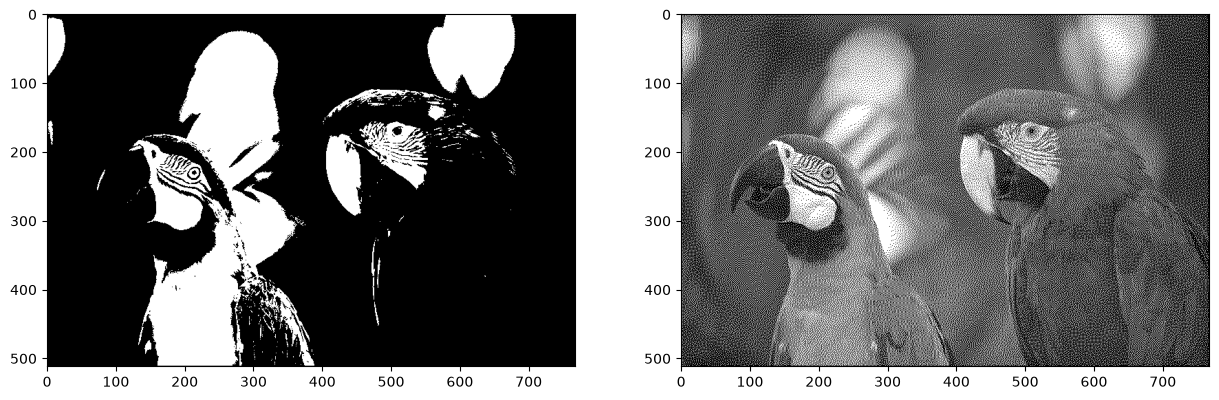

In [152]:
# color palette with balck and white 
colors = [[0, 0, 0], [255, 255, 255]]

quantized = quantize_image(img, colors)
dithering = fs_dithering(img, colors)

plt.subplot(121), plt.imshow(quantized)   # optimally quantized
plt.subplot(122), plt.imshow(dithering)   # dithering

avg_quant_error = avg_quantization_error(img, quantized)
print("avg quant error for quantized img: ", avg_quant_error)
# Compute average quantization error for dithered image
avg_dith_error = avg_quantization_error(img, dithering)
print("avg quant error for quantized img: ", avg_dith_error)

### Bonus Points

Repeat the homework using a different image palette. For instance, you can use an optimal colour
palette that we can calculate via k-means algorithm. The following snippet of code will give you the 16
optimal colours for your original image.

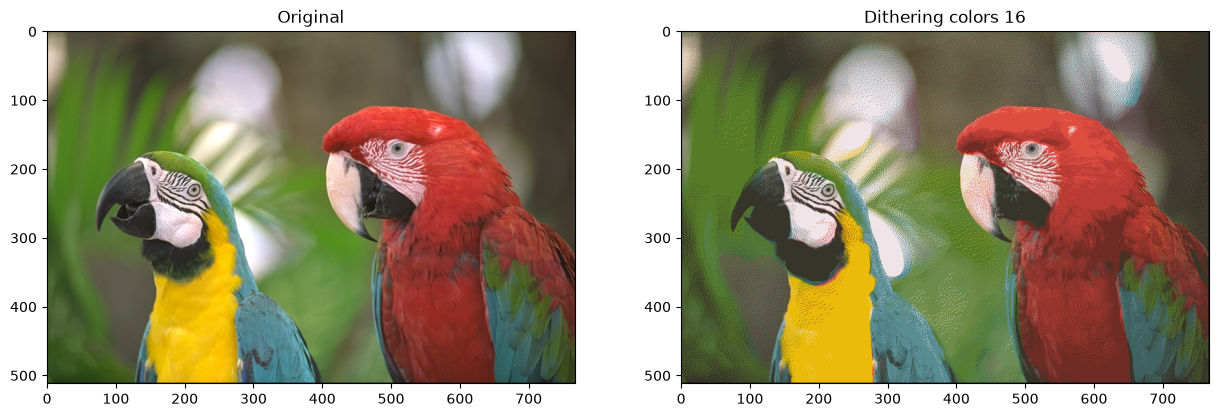

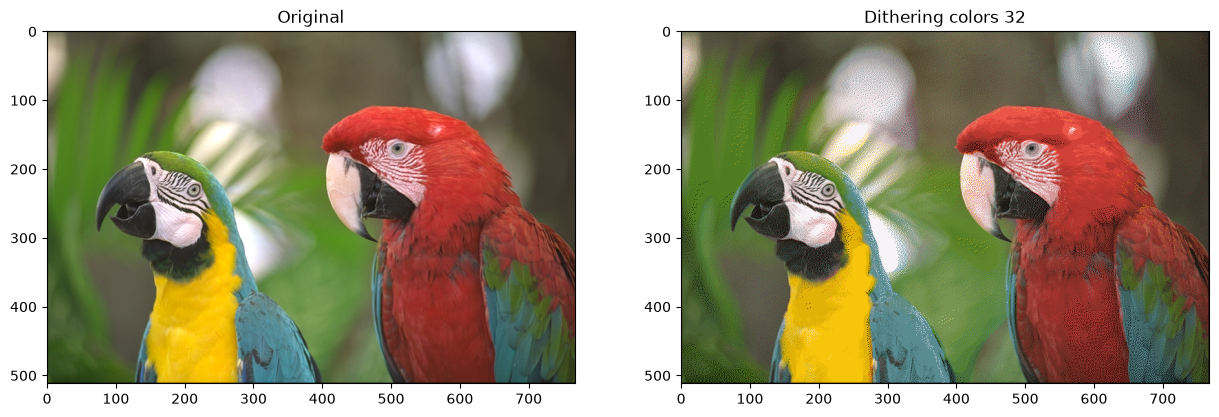

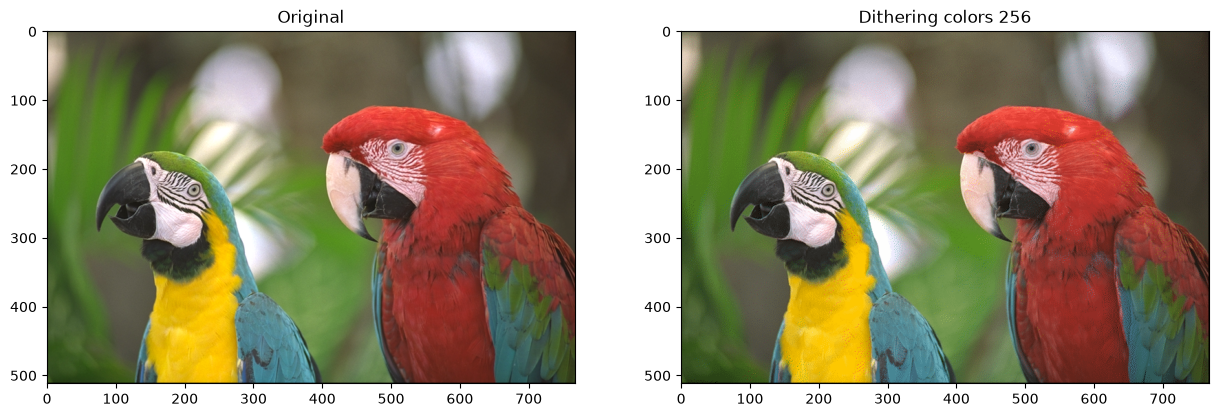

In [154]:
from sklearn.cluster import KMeans

def display_image(img, title="", show_axis = True):
    if isinstance(img, list):
        plt.figure()
        for idx, image in enumerate(img):
            plt.subplot(1,len(img),idx+1)
            plt.imshow(image)
            plt.title(title[idx])
    else:
        plt.figure()
        plt.imshow(img)
        plt.title(title)
    
    if show_axis == False:
        plt.axis('off')

clusters = [16, 32, 256]

for cluster in clusters:
    kmeans = KMeans(n_clusters=cluster).fit(np.reshape(img, (-1, 3)))
    colors = kmeans.cluster_centers_
    dithering = fs_dithering(img, colors)
    display_image([img, dithering], ["Original", "Dithering colors %d" % len(colors)])

Apply FS dithering the same way you did before.
* Q: How does the result look like to you?

  A: Even applying only 16 colors palette preserves image really well preservers the colors, but being pretty noisy, the more colors the introduce in palette the less noise we see 
* What happens if we use 32 colours?

  A: In comparrison with the 16 colors image - we see less noise introduced and more clear image
* And what happens if we use 256 colours?

  A: First of all it will be a very time consuming operation for us, since we itarate over all the pixels (except 1 row and last column), we will still some noise on some parts of the image, but in general this noise is not so visible, by having such a big palette we will still obtain very close to the original image.